Shape: (1338, 7)
   age     sex    bmi  children smoker     region    charges
0   19  female 27.900         0    yes  southwest 16,884.924
1   18    male 33.770         1     no  southeast  1,725.552
2   28    male 33.000         3     no  southeast  4,449.462
3   33    male 22.705         0     no  northwest 21,984.471
4   32    male 28.880         0     no  northwest  3,866.855
5   31  female 25.740         0     no  southeast  3,756.622
6   46  female 33.440         1     no  southeast  8,240.590
7   37  female 27.740         3     no  northwest  7,281.506
8   37    male 29.830         2     no  northeast  6,406.411
9   60  female 25.840         0     no  northwest 28,923.137

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3  

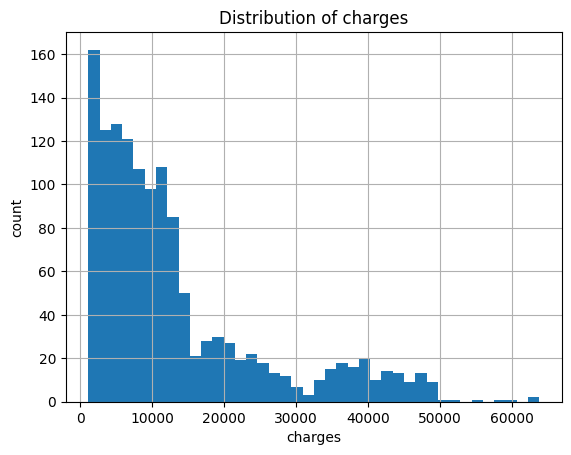


Numeric correlation with target:
           age   bmi  children  charges
age      1.000 0.109     0.042    0.299
bmi      0.109 1.000     0.013    0.198
children 0.042 0.013     1.000    0.068
charges  0.299 0.198     0.068    1.000

Group stats by: sex
        count       mean    median        std
sex                                          
male      676 13,956.751 9,369.616 12,971.026
female    662 12,569.579 9,412.962 11,128.704

Group stats by: smoker
        count       mean     median        std
smoker                                        
yes       274 32,050.232 34,456.348 11,541.547
no       1064  8,434.268  7,345.405  5,993.782

Group stats by: region
           count       mean     median        std
region                                           
southeast    364 14,735.411  9,294.132 13,971.099
northeast    324 13,406.385 10,057.652 11,255.803
northwest    325 12,417.575  8,965.796 11,072.277
southwest    325 12,346.937  8,798.593 11,557.179

Baseline 5-fold CV R^2: 

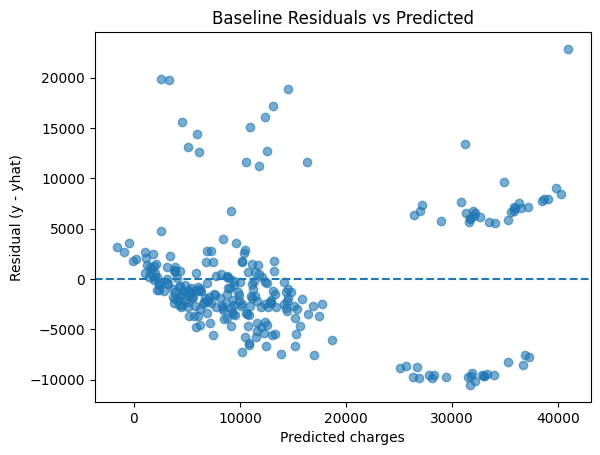

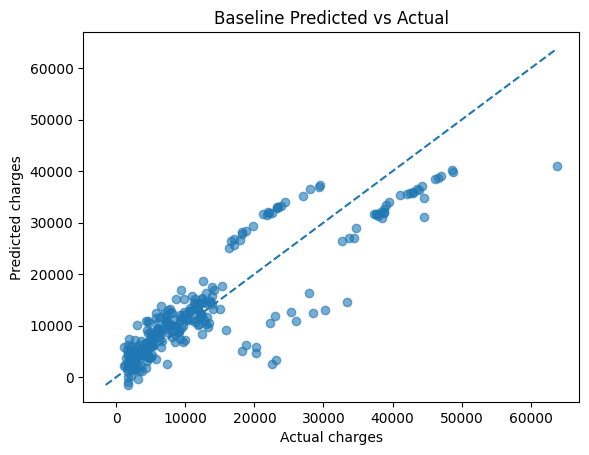


=== Ridge (original target) ===
Train | MAE:  4,218.86
Train | RMSE: 6,105.87
Train | R^2:  0.7417
Test  | MAE:  4,195.01
Test  | RMSE: 5,801.14
Test  | R^2:  0.7832
Ridge (original target) 5-fold CV R^2: [0.7834 0.738  0.7955 0.6334 0.7508] | mean: 0.7402

=== Lasso (original target) ===
Train | MAE:  4,228.08
Train | RMSE: 6,117.08
Train | R^2:  0.7407
Test  | MAE:  4,239.77
Test  | RMSE: 5,846.60
Test  | R^2:  0.7798
Lasso (original target) 5-fold CV R^2: [0.7816 0.7384 0.7956 0.6343 0.7508] | mean: 0.7402

=== ElasticNet (original target) ===
Train | MAE:  4,228.08
Train | RMSE: 6,117.08
Train | R^2:  0.7407
Test  | MAE:  4,239.77
Test  | RMSE: 5,846.60
Test  | R^2:  0.7798
ElasticNet (original target) 5-fold CV R^2: [0.7816 0.7384 0.7955 0.6343 0.7508] | mean: 0.7401

=== Ridge + Poly (log-target) ===
Train | MAE:  4,147.48
Train | RMSE: 7,931.48
Train | R^2:  0.5641
Test  | MAE:  3,977.53
Test  | RMSE: 8,066.17
Test  | R^2:  0.5809
Ridge + Poly 5-fold CV R^2 (log-space): [0.8081

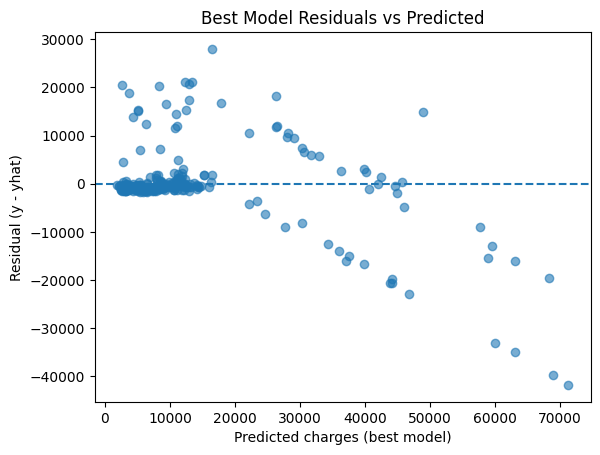

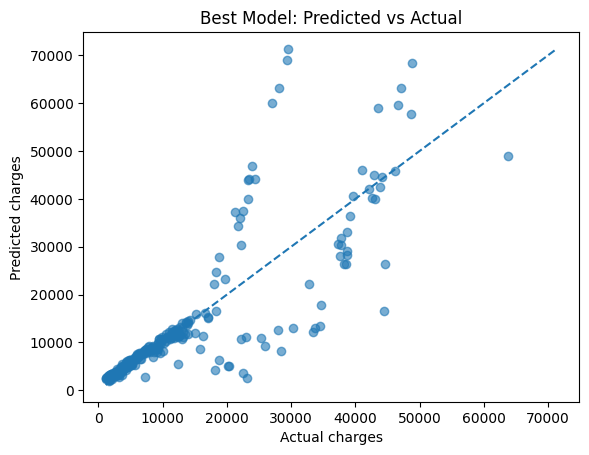


Top 15 coefficients (by magnitude) in log-space:
smoker_yes          1.550
age                 0.459
children            0.118
region_southwest   -0.114
region_southeast   -0.113
bmi                 0.090
age children       -0.078
sex_male           -0.076
region_northwest   -0.049
age^2              -0.035
bmi^2              -0.028
children^2         -0.016
age bmi            -0.011
bmi children        0.008
dtype: float64

Saved best model to insurance_cost_model.pkl


In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

RANDOM_STATE = 42
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


URL = "https://breathecode.herokuapp.com/asset/internal-link?id=416&path=medical_insurance_cost.csv"
df = pd.read_csv(URL)

print("Shape:", df.shape)
print(df.head(10))


print("\nInfo:")
print(df.info())
print("\nNulls per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())


print("\nDescribe (numeric):")
print(df.describe())


plt.figure()
df["charges"].hist(bins=40)
plt.title("Distribution of charges")
plt.xlabel("charges")
plt.ylabel("count")
plt.show()

num_cols = ["age", "bmi", "children", "charges"]
print("\nNumeric correlation with target:")
print(df[num_cols].corr())

for cat in ["sex", "smoker", "region"]:
    print(f"\nGroup stats by: {cat}")
    print(df.groupby(cat)["charges"].agg(["count","mean","median","std"]).sort_values("mean", ascending=False))


X = df.drop(columns=["charges"])
y = df["charges"]

categorical = ["sex", "smoker", "region"]
numeric = ["age", "bmi", "children"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)


cat_pre = OneHotEncoder(drop="first", handle_unknown="ignore")
num_pre = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pre, numeric),
        ("cat", cat_pre, categorical),
    ],
    remainder="drop"
)


linreg = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", LinearRegression())
])

linreg.fit(X_train, y_train)
pred_train = linreg.predict(X_train)
pred_test  = linreg.predict(X_test)

def report_metrics(y_true, y_pred, label=""):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2   = r2_score(y_true, y_pred)
    print(f"{label}MAE:  {mae:,.2f}")
    print(f"{label}RMSE: {rmse:,.2f}")
    print(f"{label}R^2:  {r2:,.4f}")

def report_metrics(y_true, y_pred, label=""):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  
    r2   = r2_score(y_true, y_pred)
    print(f"{label}MAE:  {mae:,.2f}")
    print(f"{label}RMSE: {rmse:,.2f}")
    print(f"{label}R^2:  {r2:,.4f}")



cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(linreg, X, y, scoring="r2", cv=cv)
print("\nBaseline 5-fold CV R^2:", np.round(cv_scores, 4), "| mean:", np.mean(cv_scores).round(4))

plt.figure()
resid = y_test - pred_test
plt.scatter(pred_test, resid, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.title("Baseline Residuals vs Predicted")
plt.xlabel("Predicted charges")
plt.ylabel("Residual (y - yhat)")
plt.show()


plt.figure()
plt.scatter(y_test, pred_test, alpha=0.6)
min_v = min(y_test.min(), pred_test.min())
max_v = max(y_test.max(), pred_test.max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
plt.title("Baseline Predicted vs Actual")
plt.xlabel("Actual charges")
plt.ylabel("Predicted charges")
plt.show()


alphas = np.logspace(-3, 3, 50)

ridge = RidgeCV(alphas=alphas, cv=5, scoring="r2")
lasso = LassoCV(alphas=alphas, cv=5, random_state=RANDOM_STATE)
enet  = ElasticNetCV(alphas=alphas, l1_ratio=[.1,.3,.5,.7,.9,.95,1.0], cv=5, random_state=RANDOM_STATE)

def fit_and_score_linear(name, base_prep, model, Xtr, ytr, Xte, yte, cv_all):
    pipe = Pipeline(steps=[("prep", base_prep), ("model", model)])
    pipe.fit(Xtr, ytr)
    pred_tr = pipe.predict(Xtr)
    pred_te = pipe.predict(Xte)

    print(f"\n=== {name} ===")
    report_metrics(ytr, pred_tr, label="Train | ")
    report_metrics(yte, pred_te, label="Test  | ")
    scores = cross_val_score(pipe, X, y, scoring="r2", cv=cv_all)
    print(f"{name} 5-fold CV R^2:", np.round(scores,4), "| mean:", np.mean(scores).round(4))
    return pipe

ridge_pipe = fit_and_score_linear("Ridge (original target)", preprocessor, ridge, X_train, y_train, X_test, y_test, cv)
lasso_pipe = fit_and_score_linear("Lasso (original target)", preprocessor, lasso, X_train, y_train, X_test, y_test, cv)
enet_pipe  = fit_and_score_linear("ElasticNet (original target)", preprocessor, enet,  X_train, y_train, X_test, y_test, cv)


y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

poly_num = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False, interaction_only=False))
])

preprocessor_poly = ColumnTransformer(
    transformers=[
        ("num_poly", poly_num, numeric),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical),
    ],
    remainder="drop"
)

def fit_and_score_log_target(name, base_prep, model):
    pipe = Pipeline(steps=[("prep", base_prep), ("model", model)])
    pipe.fit(X_train, y_train_log)

    pred_tr_log = pipe.predict(X_train)
    pred_te_log = pipe.predict(X_test)
    pred_tr = np.expm1(pred_tr_log)
    pred_te = np.expm1(pred_te_log)

    print(f"\n=== {name} (log-target) ===")
    report_metrics(y_train, pred_tr, label="Train | ")
    report_metrics(y_test,  pred_te, label="Test  | ")

    scores = cross_val_score(pipe, X, np.log1p(y), scoring="r2", cv=cv)
    print(f"{name} 5-fold CV R^2 (log-space):", np.round(scores,4), "| mean:", np.mean(scores).round(4))
    return pipe, pred_te

ridge_log = RidgeCV(alphas=alphas, cv=5, scoring="r2")
lasso_log = LassoCV(alphas=alphas, cv=5, random_state=RANDOM_STATE)
enet_log  = ElasticNetCV(alphas=alphas, l1_ratio=[.1,.3,.5,.7,.9,.95,1.0], cv=5, random_state=RANDOM_STATE)

ridge_log_pipe, ridge_log_pred = fit_and_score_log_target("Ridge + Poly", preprocessor_poly, ridge_log)
lasso_log_pipe, lasso_log_pred = fit_and_score_log_target("Lasso  + Poly", preprocessor_poly, lasso_log)
enet_log_pipe,  enet_log_pred  = fit_and_score_log_target("ElasticNet + Poly", preprocessor_poly, enet_log)

best_pipe = enet_log_pipe
best_pred = enet_log_pred

plt.figure()
resid_best = y_test - best_pred
plt.scatter(best_pred, resid_best, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.title("Best Model Residuals vs Predicted")
plt.xlabel("Predicted charges (best model)")
plt.ylabel("Residual (y - yhat)")
plt.show()

plt.figure()
plt.scatter(y_test, best_pred, alpha=0.6)
min_v = min(y_test.min(), best_pred.min())
max_v = max(y_test.max(), best_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
plt.title("Best Model: Predicted vs Actual")
plt.xlabel("Actual charges")
plt.ylabel("Predicted charges")
plt.show()


prep = best_pipe.named_steps["prep"]
model = best_pipe.named_steps["model"]

num_feats_poly = prep.transformers_[0][1].named_steps["poly"].get_feature_names_out(numeric)
cat_feats = prep.transformers_[1][1].get_feature_names_out(categorical)
feat_names = np.r_[num_feats_poly, cat_feats]

coefs = pd.Series(model.coef_, index=feat_names).sort_values(key=np.abs, ascending=False)
print("\nTop 15 coefficients (by magnitude) in log-space:")
print(coefs.head(15))


joblib.dump(best_pipe, "insurance_cost_model.pkl")
print("\nSaved best model to insurance_cost_model.pkl")
